In [ ]:
# Install AerEO and any required plugins for this notebook (Google Colab)
!pip install -q "aereo[swath,viz]" aereo-read-satpy aereo-search-aws-goes

In [ ]:
# Download config files and AOIs from the GitHub repository so this
# notebook can run outside the repo (e.g. Google Colab).
import os
import urllib.request

GITHUB_RAW = "https://raw.githubusercontent.com/frandorr/aereo/main"

os.makedirs("config/aoi", exist_ok=True)

# Config files
urllib.request.urlretrieve(
    f"{GITHUB_RAW}/examples/config/job_viirs.yaml",
    "config/job_viirs.yaml",
)
urllib.request.urlretrieve(
    f"{GITHUB_RAW}/examples/config/job_goes19.yaml",
    "config/job_goes19.yaml",
)

# AOI files
urllib.request.urlretrieve(
    f"{GITHUB_RAW}/examples/config/aoi/chocon.geojson",
    "config/aoi/chocon.geojson",
)
urllib.request.urlretrieve(
    f"{GITHUB_RAW}/examples/config/aoi/cordoba.geojson",
    "config/aoi/cordoba.geojson",
)

### NASA Earthdata authentication

The NASA notebooks need a valid `~/.netrc` file. Run this cell once in Colab to create it from your credentials:

```python
import os
from getpass import getpass

# Get Earthdata credentials from the user
earthdata_username = getpass("Earthdata username: ")
earthdata_password = getpass("Earthdata password: ")

# Define the path for the .netrc file in the user's home directory
netrc_path = os.path.expanduser("~/.netrc")

# Create the .netrc file with the provided credentials
with open(netrc_path, "w") as f:
    f.write("machine urs.earthdata.nasa.gov login {username} password {password}\n".format(
        username=earthdata_username,
        password=earthdata_password
    ))

# Set permissions for the .netrc file to be readable only by the owner
os.chmod(netrc_path, 0o600)

print(f"Successfully created {netrc_path} for Earthdata authentication.")
```


## Configs used in this notebook

This notebook loads **two** jobs and aligns them to the same AOI:

- `examples/config/job_viirs.yaml` (see the VIIRS tutorial for the full file)
- `examples/config/job_goes19.yaml` (see the GOES-19 tutorial for the full file)

Both jobs are loaded with Hydra overrides so they use the same AOI and the VIIRS job uses a coarser alignment resolution:

```python
viirs_job = ExtractionJob.load_from_config(
    config_dir="config",
    config_name="job_viirs",
    overrides=[
        "target_aoi=config/aoi/cordoba.geojson",
        "search.intersects=config/aoi/cordoba.geojson",
        "grid_resolution=400",
        "+alignment_resolution=2000",
    ],
)

goes_job = ExtractionJob.load_from_config(
    config_dir="config",
    config_name="job_goes19",
    overrides=[
        "target_aoi=config/aoi/cordoba.geojson",
        "search.intersects=config/aoi/cordoba.geojson",
    ],
)
```


In [1]:
from aereo.cache import TaskResultCache
from aereo.executors import LocalExecutor
from aereo.pipeline import ExtractionJob

target_aoi_path = "config/aoi/cordoba.geojson"
# Load the job from the Hydra config package.
viirs_job = ExtractionJob.load_from_config(
    config_dir="config",
    config_name="job_viirs",
    overrides=[
        "target_aoi=config/aoi/cordoba.geojson",
        "search.intersects=config/aoi/cordoba.geojson",
        "grid_resolution=400",
        "+alignment_resolution=2000",
    ],
)

goes_job = ExtractionJob.load_from_config(
    config_dir="config",
    config_name="job_goes19",
    overrides=[
        "target_aoi=config/aoi/cordoba.geojson",
        "search.intersects=config/aoi/cordoba.geojson",
    ],
)

In [2]:
# lets change daterange for the viirs search
viirs_assets = viirs_job.search(
    start_datetime="2026-01-01T10:00:00Z",
    end_datetime="2026-01-01T23:00:00Z",
    intersects=viirs_job.target_aoi,
)

2026-07-08 17:00:28 [info     ] search_called                  provider=search_earthaccess


/root/repos/aereo/.venv/lib/python3.13/site-packages/earthaccess/results.py:348: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  self["size"] = self.size()
/root/repos/aereo/components/aereo/builtins/search.py:324: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  size_mb = g.size()


In [3]:
# now, lets get the viirs asset start_time and end_time and search the corresponding goes-19 assets
start_time = viirs_assets.iloc[0].start_time
end_time = viirs_assets.iloc[0].end_time

In [4]:
goes19_assets = goes_job.search(start_datetime=start_time, end_datetime=end_time)

2026-07-08 17:00:37 [info     ] search_called                  provider=search_aws_goes


In [5]:
viirs_tasks = viirs_job.build_tasks(viirs_assets)
goes_tasks = goes_job.build_tasks(goes19_assets)

2026-07-08 17:00:39 [info     ] build_tasks_start              assets=2 builder=build_grouped_tasks
2026-07-08 17:00:39 [info     ] build_tasks_start              assets=2 builder=build_grouped_tasks


/root/repos/aereo/.venv/lib/python3.13/site-packages/pydantic/_internal/_validate_call.py:137: UserWarning: assets has no 'crs' column; assuming all assets share the same native CRS. Mixed-CRS assets in one task may fail or produce incorrect results.
  res = self.__pydantic_validator__.validate_python(pydantic_core.ArgsKwargs(args, kwargs))
/root/repos/aereo/.venv/lib/python3.13/site-packages/pydantic/_internal/_validate_call.py:137: UserWarning: assets has no 'crs' column; assuming all assets share the same native CRS. Mixed-CRS assets in one task may fail or produce incorrect results.
  res = self.__pydantic_validator__.validate_python(pydantic_core.ArgsKwargs(args, kwargs))


In [6]:
# now we create an Executor, in this case a LocalExecutor to run
local_exec = LocalExecutor(workers=2, use_threads=False, cache=TaskResultCache())

In [ ]:
# Extract!
viirs_artifacts = viirs_job.execute(viirs_tasks, executor=local_exec)

In [8]:
# Extract!
goes_artifacts = goes_job.execute(goes_tasks, executor=local_exec)

2026-07-08 17:01:59 [info     ] execute_start                  executor=LocalExecutor task_count=2
2026-07-08 17:02:02 [debug    ] file_downloaded                engine=satpy local_path=/tmp/aereo_extraction/OR_ABI-L1b-RadF-M6C07_G19_s20260011810226_e20260011819546_c20260011819586.nc
2026-07-08 17:02:14 [debug    ] file_downloaded                engine=satpy local_path=/tmp/aereo_extraction/OR_ABI-L1b-RadF-M6C07_G19_s20260011800226_e20260011809546_c20260011809589.nc


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


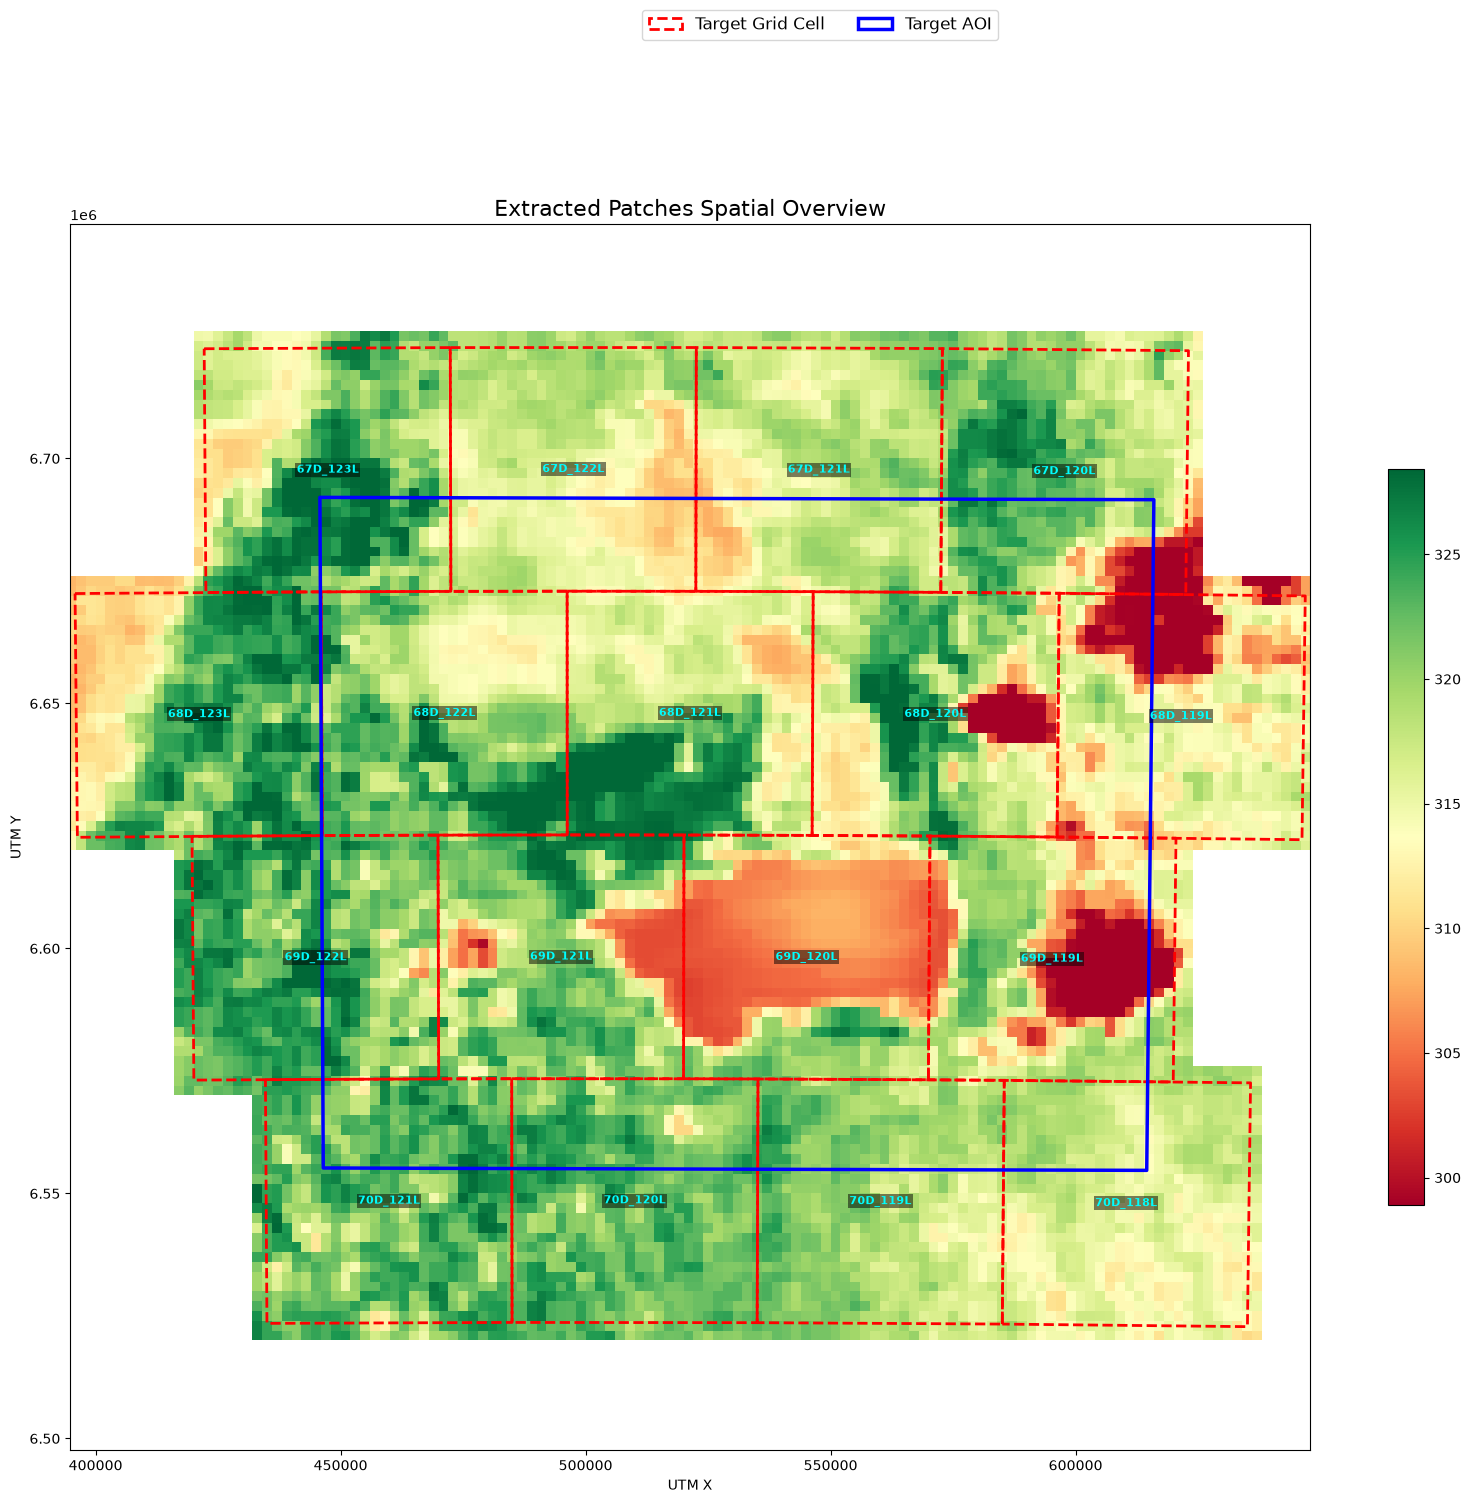

In [9]:
from aereo.viz import plot_artifact_patches

fig, ax = plot_artifact_patches(
    goes_artifacts,
    ds_factor=1,
    stretch="percentile",
    cmap="RdYlGn",
    aoi=goes_job.target_aoi,
    aoi_edgecolor="blue",
)

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


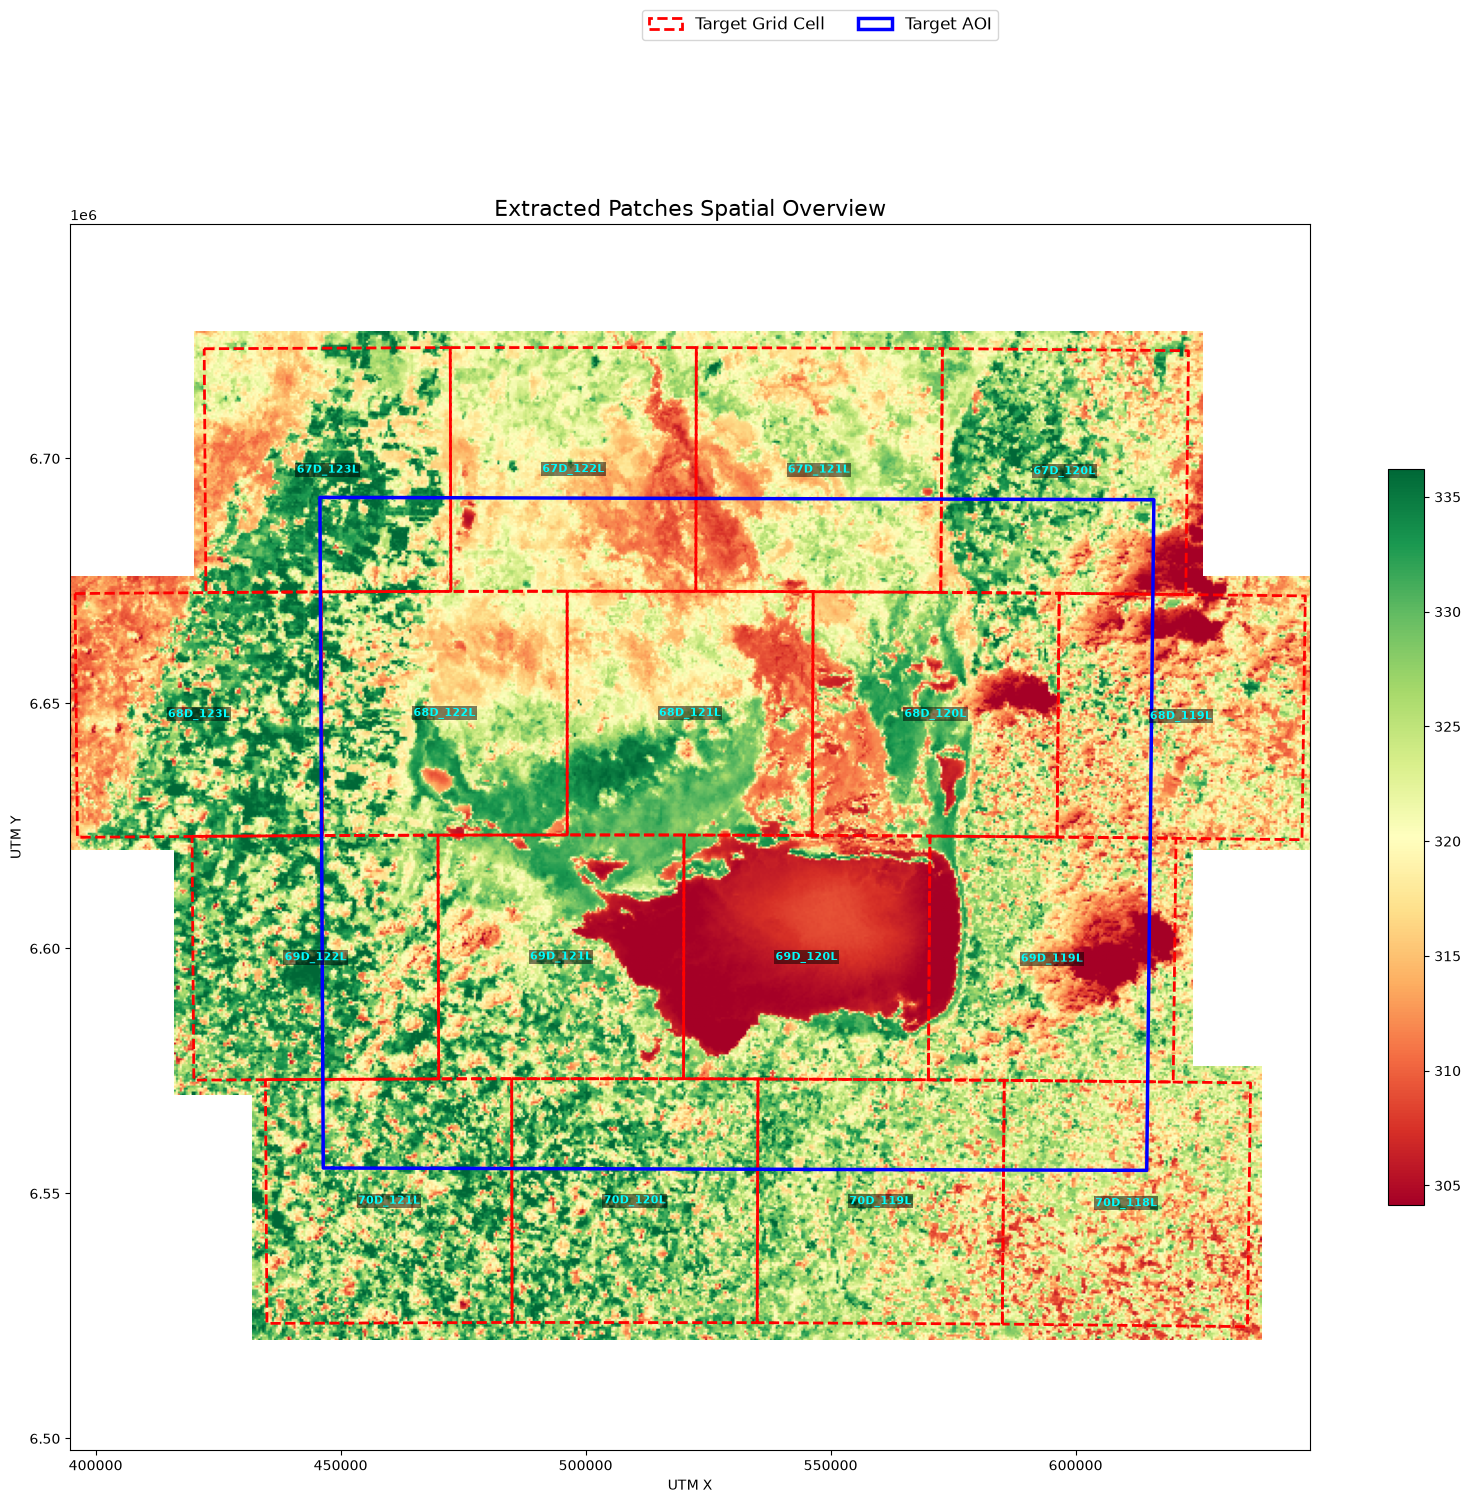

In [11]:
fig, ax = plot_artifact_patches(
    viirs_artifacts,
    ds_factor=1,
    stretch="percentile",
    cmap="RdYlGn",
    aoi=viirs_job.target_aoi,
    aoi_edgecolor="blue",
)

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


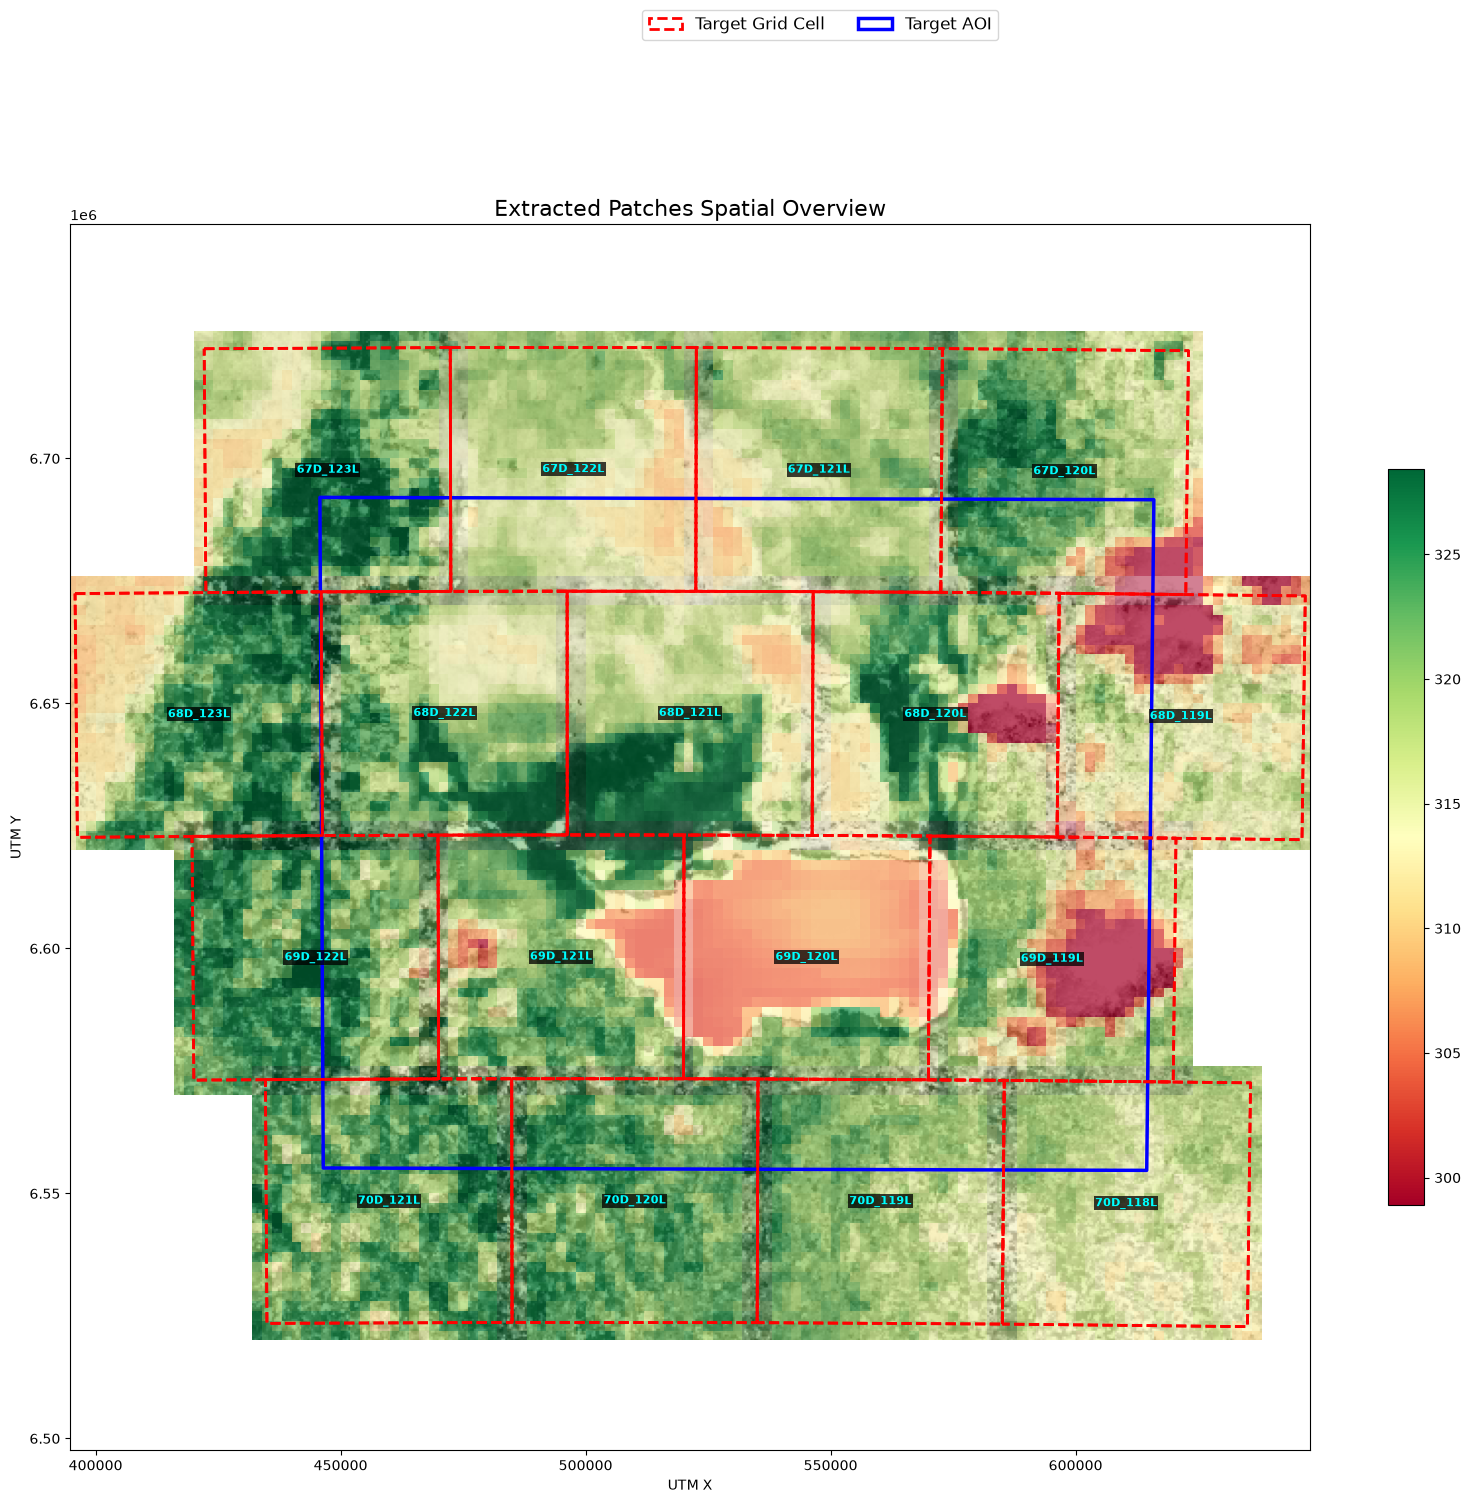

In [12]:
from aereo.viz import plot_artifact_patches

fig, ax = plot_artifact_patches(
    goes_artifacts,
    ds_factor=1,
    stretch="percentile",
    cmap="RdYlGn",
    aoi=goes_job.target_aoi,
    aoi_edgecolor="blue",
)
fig, ax = plot_artifact_patches(
    viirs_artifacts, ds_factor=1, stretch="percentile", cmap="Grays", ax=ax, alpha=0.3
)